In [1]:
import numpy as np
import numpy as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [3]:
import pandas as pd

df = pd.read_csv("insurance.csv")

print(df.head(10))

   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86
5   31  female  25.7         0     no  southeast   3756.62
6   46  female  33.4         1     no  southeast   8240.59
7   37  female  27.7         3     no  northwest   7281.51
8   37    male  29.8         2     no  northeast   6406.41
9   60  female  25.8         0     no  northwest  28923.14


In [4]:
# Shape
print("Shape:", df.shape)

# Information
print(df.info())

# Statistical Summary
print(df.describe())

Shape: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children      expenses
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.665471     1.094918  13270.422414
std      14.049960     6.098382     1.205493  12110.011240
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4740.287500
50%      39.000000    30.400000     1.000000   9382.030000
75%      51.000000    34.700000     2.000000 

In [5]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


In [6]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['age', 'bmi', 'children', 'expenses'], dtype='object')

Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='object')


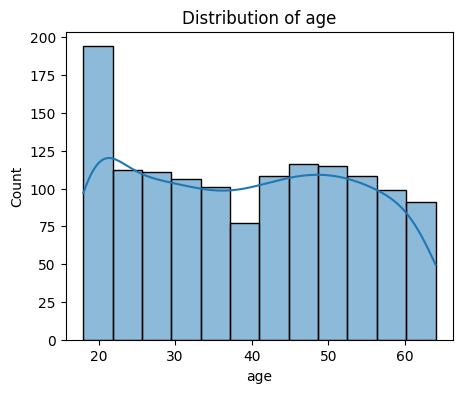

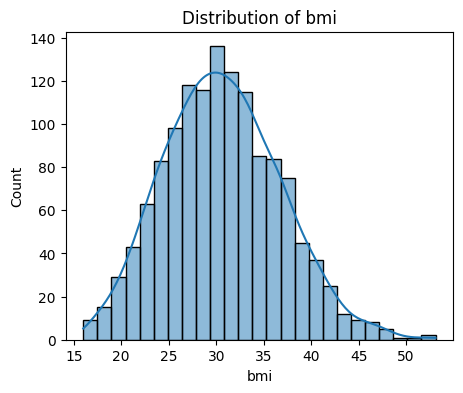

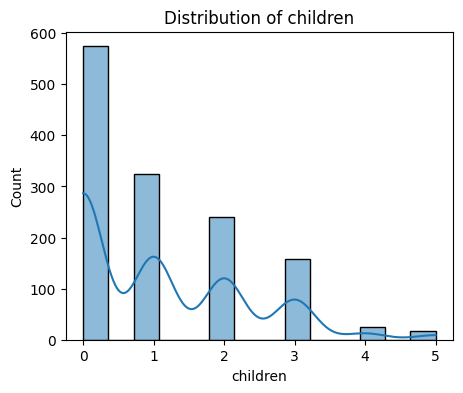

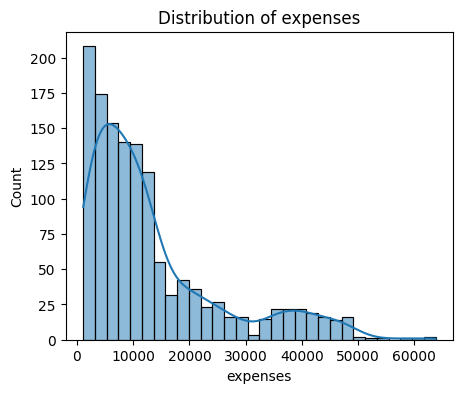

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

columns = ["age", "bmi", "children", "expenses"]

for col in columns:
    plt.figure(figsize=(5,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

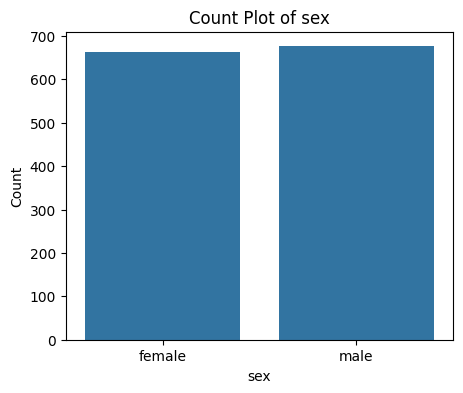

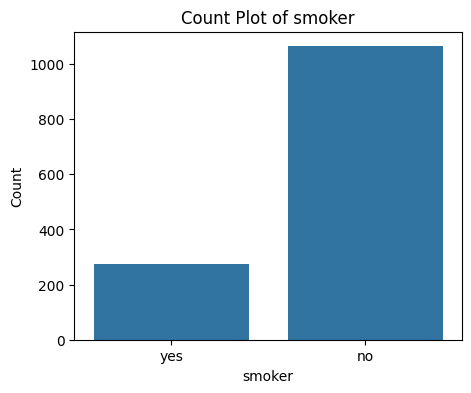

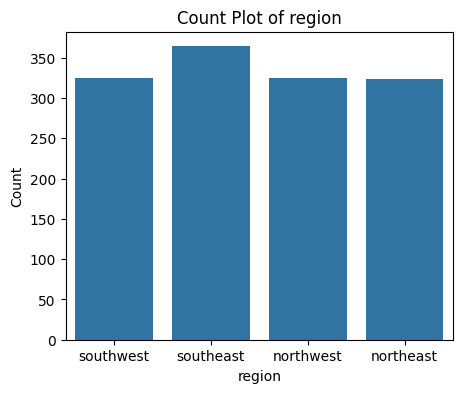

In [8]:
cat_cols = ["sex", "smoker", "region"]

for col in cat_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

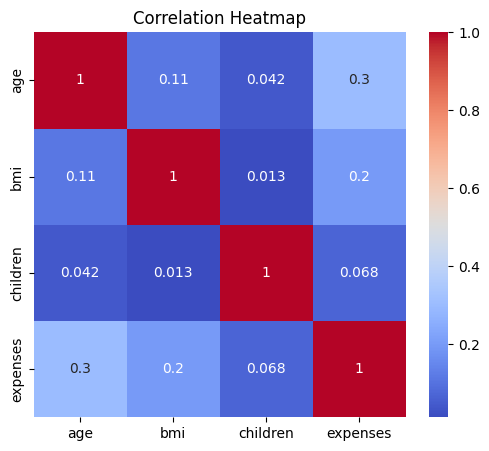

In [9]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
print("Average Charges:", df["expenses"].mean())
print("Maximum Charges:", df["expenses"].max())
print("Minimum Charges:", df["expenses"].min())

print("\nAverage Charges by Smoker:")
print(df.groupby("smoker")["expenses"].mean())

Average Charges: 13270.422414050823
Maximum Charges: 63770.43
Minimum Charges: 1121.87

Average Charges by Smoker:
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64


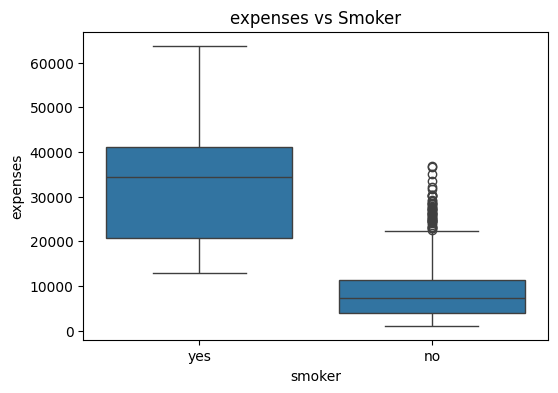

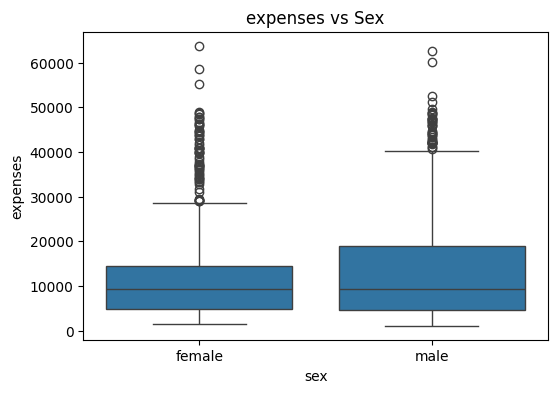

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x="smoker", y="expenses", data=df)
plt.title("expenses vs Smoker")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="sex", y="expenses", data=df)
plt.title("expenses vs Sex")
plt.show()

In [13]:
# Average Age
print("Average Age:", df["age"].mean())

# Average BMI
print("Average BMI:", df["bmi"].mean())

# Region with highest customers
print("Highest Customers Region:")
print(df["region"].value_counts())

Average Age: 39.20702541106129
Average BMI: 30.66547085201794
Highest Customers Region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
